<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/kmeans_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
iris = load_iris()
X = iris.data[:, :2]

In [ ]:
X[:5]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

In [ ]:
wcss = []
k_range = range(1, 11)

In [ ]:
for k in k_range:
  kmean_algo = KMeans(n_clusters=k, random_state=42)
  kmean_algo.fit(X)
  wcss.append(kmean_algo.inertia_)


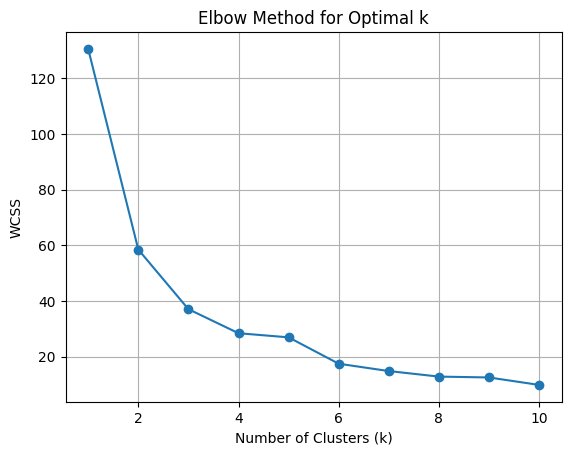

In [ ]:
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
# plt.xticks(list(k_range))
plt.grid(True)
plt.show()

In [ ]:
kmean_algo_final = KMeans(n_clusters=2)
cluster_label = kmean_algo_final.fit_predict(X)

In [ ]:
X_df = pd.DataFrame(X, columns=['sepal_length', 'sepal_width'])
X_df['cluster_label'] = cluster_label
X = X_df

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

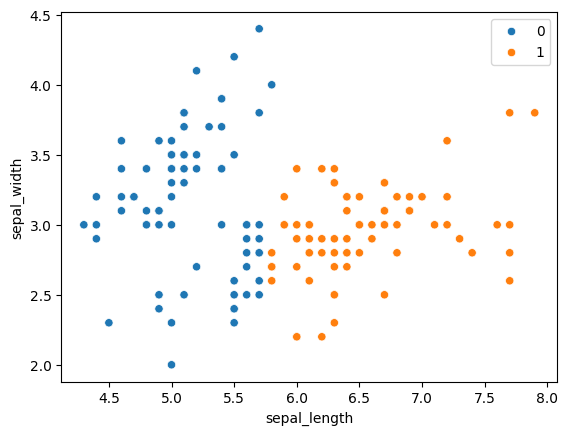

In [ ]:
feature_x = X.columns[0]
feature_y = X.columns[1]
sns.scatterplot(x=feature_x, y=feature_y, hue=cluster_label, data=X)

In [ ]:
import joblib

joblib.dump(kmean_algo_final, "kmeans_model.joblib")

print("KMeans model saved successfully")

KMeans model saved successfully


In [ ]:
X.to_csv("iris_data.csv", index=False)